<a href="https://colab.research.google.com/github/Faseeh555/Diabetes-Prediction-ML/blob/main/Internship_Feedback_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    precision_score,
    f1_score,
    recall_score,
    classification_report
)
import joblib
import string
import streamlit as st

In [93]:
#load data set
data = pd.read_csv('internship_feedback_sentiment_v3.csv')
data.head()

,Feedback_ID,Internship_Domain,Internship_Mode,Duration_Months,Feedback,Sentiment,Sentiment_Label,Is_Mixed_Sentiment,Aspects_Mentioned
0,FB00001,Software Testing,Hybrid,8,"Compared to what I expected, the remote work s...",Positive,1,No,"remote, balance"
1,FB00002,Data Science,Hybrid,3,"In short, the learning opportunities was explo...",Negative,0,No,"learning, flex, workload"
2,FB00003,Web Development,Hybrid,4,"In short, I can't complain about the manager, ...",Negative,0,No,"manager, comm"
3,FB00004,Mobile App Development,On-site,8,This experience made me way more confident abo...,Positive,1,Yes,"career, mentor, hours"
4,FB00005,Cloud Computing,On-site,4,"To be fair, instructions kept changing halfway...",Negative,0,Yes,"comm, resources, culture"


In [153]:
##dataset exploration

# data.isnull().sum()
data.columns
# data.info()
# data.describe()
# data.tail()
# data.shape
# data.duplicated().sum()
# data['Sentiment_Label'].value_counts()
# data["Sentiment"].value_counts()

Index(['Feedback_ID', 'Internship_Domain', 'Internship_Mode',
       'Duration_Months', 'Feedback', 'Sentiment', 'Sentiment_Label',
       'Is_Mixed_Sentiment', 'Aspects_Mentioned'],
      dtype='object')

In [154]:
#text processing
data['Feedback'] = data['Feedback'].str.lower()
data['Feedback'] = data['Feedback'].str.translate(
    str.maketrans(" ", " ", string.punctuation)
)
data['Feedback'] = data['Feedback'].apply(
    lambda text: " ".join(text.split())
)
data['Feedback'].head(5)

,Feedback
0,compared to what i expected the remote work se...
1,in short the learning opportunities was exploi...
2,in short i cant complain about the manager it ...
3,this experience made me way more confident abo...
4,to be fair instructions kept changing halfway ...


vectorizer = TfidfVectorizer() creates a TF-IDF Vectorizer object that we will use to convert text into numerical features.

X_train = vectorizer.fit_transform(X_train) learns the vocabulary and IDF values from the training text and then converts the training reviews into TF-IDF numerical features.

X_test = vectorizer.transform(X_test) converts the test reviews into numerical features using the vocabulary and IDF values already learned from the training data. We don't use fit() on the test data because it could cause data leakage.

In [96]:
#input and target
X = data['Feedback']
y = data['Sentiment_Label']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

#tf-idf
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [97]:
#logistic regression
lr_model = LogisticRegression(
    random_state = 42
)
#model training
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(random_state=42)

In [98]:
#predictions
y_pred = lr_model.predict(X_test_tfidf)
print(y_pred[:10])

[0 0 1 1 0 1 0 0 0 1]


In [99]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)
print("\n")

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\n")

#Precision
precision = precision_score(y_test, y_pred)
print("Precsion: ", precision)
print("\n")

#Recall
recall = recall_score(y_test, y_pred)
print("Recall: ", recall)
print("\n")

#F1_score
f1 = f1_score(y_test, y_pred)
print("F1_score: ", f1)
print("\n")

#Classification Report
cr = classification_report(y_test, y_pred)
print("Classification Report:\n", cr)

Accuracy:  0.97375


Confusion Matrix:
 [[381   7]
 [ 14 398]]


Precsion:  0.9827160493827161


Recall:  0.9660194174757282


F1_score:  0.9742962056303549


Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       388
           1       0.98      0.97      0.97       412

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



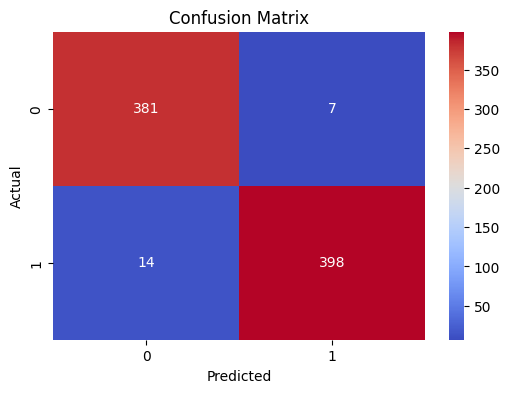

In [100]:
#heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "coolwarm"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [151]:
#new feedback predicition
new_feedback = ["My mentors are really helpful "]
new_feedback_tfidf = vectorizer.transform(new_feedback)
prediction = lr_model.predict(new_feedback_tfidf)

Your feedback is positive.
[[0.16330557 0.83669443]]


In [113]:
#save model
joblib.dump(lr_model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['sentiment_model.pkl']

In [129]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 38.8 MB/s eta 0:00:00


In [141]:
%%writefile app.py

import streamlit as st

st.title("Intern Feedback Sentiment Analyzer")

Overwriting app.py


In [142]:
!pip install -q streamlit pyngrok

In [143]:
!streamlit run app.py &>/content/logs.txt &

In [144]:
!ngrok config add-authtoken 3HrOnBUl7RWWMtleROjmO17STPZ_7ZKfB8RMADEUu1jqFVrwf

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [145]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://drained-singing-rubbed.ngrok-free.dev" -> "http://localhost:8501"


In [149]:
%%writefile app.py

import streamlit as st
import joblib

# -----------------------------
# Load trained model and vectorizer
# -----------------------------

loaded_model = joblib.load("sentiment_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")


# -----------------------------
# Page title
# -----------------------------

st.title("Intern Feedback Sentiment Analyzer")

st.write(
    "Enter your internship feedback below and the model will predict its sentiment."
)


# -----------------------------
# Feedback input
# -----------------------------

feedback = st.text_area(
    "Enter your feedback:",
    placeholder="Example: My mentor was very helpful and I learned a lot..."
)


# -----------------------------
# Analyze button
# -----------------------------

if st.button("Analyze Sentiment"):

    if feedback.strip() == "":
        st.warning("Please enter some feedback first.")

    else:

        # Convert feedback into TF-IDF features
        feedback_tfidf = loaded_vectorizer.transform([feedback])

        # Predict sentiment
        prediction = loaded_model.predict(feedback_tfidf)

        # Get probabilities
        probability = loaded_model.predict_proba(feedback_tfidf)

        negative_probability = probability[0][0] * 100
        positive_probability = probability[0][1] * 100

        # Display prediction
        if prediction[0] == 1:
            st.success("Your feedback is Positive.")
            st.write(
                f"Positive probability: {positive_probability:.2f}%"
            )

        else:
            st.error("Your feedback is Negative.")
            st.write(
                f"Negative probability: {negative_probability:.2f}%"
            )

Overwriting app.py


In [147]:
!pkill -f streamlit

In [148]:
!streamlit run app.py &>/content/logs.txt &

In [159]:
%%writefile requirements.txt

pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
streamlit

Writing requirements.txt


In [160]:
%%writefile .gitignore

__pycache__/
.ipynb_checkpoints/
*.pyc
.env

Writing .gitignore


In [161]:
%%writefile README.md

# Intern Feedback Sentiment Analysis

An NLP-based machine learning project that analyzes intern feedback and classifies it as Positive or Negative.

## Project Overview

The goal of this project is to analyze textual intern feedback and automatically identify its sentiment.

## Workflow

1. Load and inspect the dataset
2. Clean and preprocess feedback text
3. Split data into training and testing sets
4. Convert text into numerical features using TF-IDF
5. Train a Logistic Regression classifier
6. Evaluate the model
7. Test the model on new feedback
8. Save the trained model and TF-IDF vectorizer

## Technologies

- Python
- Pandas
- Scikit-learn
- TF-IDF
- Logistic Regression
- Matplotlib
- Seaborn
- Joblib
- Streamlit

## Model Performance

The Logistic Regression model achieved approximately 98% accuracy on the test dataset.

Evaluation metrics included:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

## Example

Input:

> My mentor was really helpful and I learned a lot.

Output:

> Positive

## Future Improvements

- Improve preprocessing
- Handle spelling variations
- Experiment with other NLP models
- Add confidence/probability visualization
- Deploy the model as a web application

Writing README.md


fatal: not a git repository (or any of the parent directories): .git
